Figure 4 in the paper: Posterior uncertainty $U_\ell[\pi^u\rhd{\sf C}]$ as the dataset size $n$ increases.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

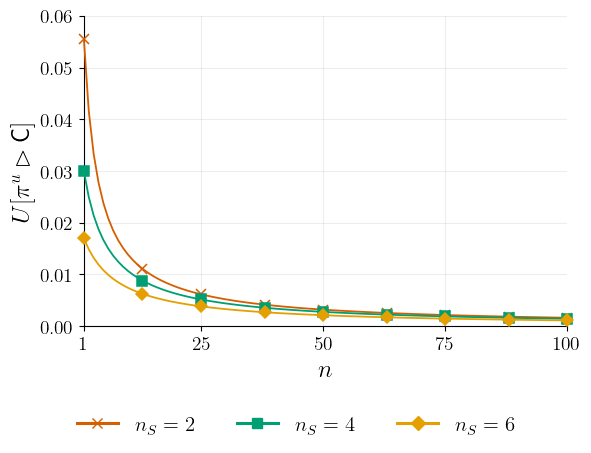

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amssymb}",
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 2.2,
    "figure.figsize": (5.8, 3.8),
})

# Parameters
n_min = 1
n_max = 100
ns_values = [2, 4, 6]

# Function:
# posterior_uncertainty(n, ns) = (ns - 1) / ((ns + 1)(n + ns)ns)
def posterior_uncertainty(n, ns):
    return (ns - 1) / ((ns + 1) * (n + ns) * ns)

# Data
n_values = np.arange(n_min, n_max + 1)

colors = {
    2: "#D55E00",
    4: "#009E73",
    6: "#E69F00",
}

markers = {
    2: "x",
    4: "s",
    6: "D",
}

fig, ax = plt.subplots(constrained_layout=True)

for ns in ns_values:
    y_values = posterior_uncertainty(n_values, ns)
    marker_idx = np.array([0, 12, 24, 37, 49, 62, 74, 87, 99])

    ax.plot(
        n_values,
        y_values,
        color=colors[ns],
        marker=markers[ns],
        markevery=marker_idx,
        markersize=6.5,
        markeredgewidth=1.1,
        linewidth=1.3,
        label=rf"$n_S = {ns}$",
        zorder=3,
        clip_on=False,
    )

ax.set_xlabel(r"$n$")
ax.set_ylabel(r"$U[\pi^u \rhd {\sf C}]$")
ax.set_xlim(n_min, n_max)
ax.set_ylim(0, 0.06)

ax.set_xticks([1, 25, 50, 75, 100])
ax.set_yticks(np.linspace(0, 0.06, 7))

ax.grid(True, which="major", axis="both", alpha=0.22, linewidth=0.8)
ax.set_axisbelow(True)

legend_handles = [
    Line2D(
        [0], [0],
        color=colors[ns],
        marker=markers[ns],
        linewidth=2.2,
        markersize=7,
        label=rf"$n_S = {ns}$"
    )
    for ns in ns_values
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.18),
)

plt.show()